In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
import pickle, os, sys, warnings
sys.path.insert(0, os.getcwd())
from utils import evaluate_model
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

os.makedirs('models', exist_ok=True)

df = pd.read_csv('data/tea_demand_dataset.csv', parse_dates=['week_start_date'])
df = df.sort_values(['grade', 'week_start_date']).reset_index(drop=True)

grades_raw = df['grade'].unique()
print("Grades:", grades_raw)

Grades: ['BOP' 'BOPF' 'Dust' 'OP' 'Pekoe']


In [2]:
LOOKBACK = 12  # 12-week input window
FEATURES  = ['demand_kg', 'colombo_auction_price_lkr',
             'usd_lkr_rate', 'rainfall_index', 'festival_flag']

# Only keep features that exist in the dataset
FEATURES = [f for f in FEATURES if f in df.columns]
print("LSTM features:", FEATURES)

def build_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])  # index 0 = demand_kg
    return np.array(X), np.array(y)

def inverse_demand(scaled_vals, scaler, n_features):
    dummy = np.zeros((len(scaled_vals), n_features))
    dummy[:, 0] = scaled_vals
    return scaler.inverse_transform(dummy)[:, 0]

LSTM features: ['demand_kg', 'colombo_auction_price_lkr', 'usd_lkr_rate', 'rainfall_index', 'festival_flag']


In [3]:
lstm_results = []
lstm_preds   = {}
lstm_actuals = {}
test_dates   = {}

for grade in grades_raw:
    print(f"\n{'='*45}")
    print(f"  Training LSTM: {grade}")
    print(f"{'='*45}")
    
    sub        = df[df['grade'] == grade].sort_values('week_start_date').reset_index(drop=True)
    train_raw  = sub[sub['year'] < 2024][FEATURES].values
    test_raw   = sub[sub['year'] >= 2024][FEATURES].values
    
    scaler       = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_raw)
    test_scaled  = scaler.transform(test_raw)
    
    full_scaled  = np.vstack([train_scaled, test_scaled])
    X_all, y_all = build_sequences(full_scaled, LOOKBACK)
    
    split    = len(train_scaled) - LOOKBACK
    X_tr, y_tr = X_all[:split], y_all[:split]
    X_te, y_te = X_all[split:], y_all[split:]
    
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOKBACK, len(FEATURES))),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='huber')
    
    callbacks = [
        EarlyStopping(patience=20, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(factor=0.5, patience=10, verbose=0)
    ]
    
    model.fit(X_tr, y_tr,
              validation_split=0.15,
              epochs=150, batch_size=16,
              callbacks=callbacks, verbose=0)
    
    pred_scaled  = model.predict(X_te, verbose=0).flatten()
    pred_kg      = inverse_demand(pred_scaled, scaler, len(FEATURES))
    actual_kg    = inverse_demand(y_te,         scaler, len(FEATURES))
    
    lstm_preds[grade]   = pred_kg
    lstm_actuals[grade] = actual_kg
    test_dates[grade]   = sub[sub['year'] >= 2024]['week_start_date'].values[LOOKBACK:]
    
    metrics = evaluate_model(f'LSTM ({grade})', actual_kg, pred_kg)
    metrics['grade'] = grade
    lstm_results.append(metrics)
    
    model.save(f'models/lstm_{grade}.keras')
    pickle.dump(scaler, open(f'models/scaler_{grade}.pkl', 'wb'))
    print(f"  Saved → models/lstm_{grade}.keras")

lstm_df = pd.DataFrame(lstm_results)
lstm_df.to_csv('results/lstm_results.csv', index=False)
print("\nAll LSTM models trained and saved.")


  Training LSTM: BOP

  Model: LSTM (BOP)
  MAE   : 385.66 kg
  RMSE  : 503.15 kg
  MAPE  : 9.26%
  sMAPE : 9.48%
  Saved → models/lstm_BOP.keras

  Training LSTM: BOPF

  Model: LSTM (BOPF)
  MAE   : 515.46 kg
  RMSE  : 631.51 kg
  MAPE  : 10.99%
  sMAPE : 11.00%
  Saved → models/lstm_BOPF.keras

  Training LSTM: Dust

  Model: LSTM (Dust)
  MAE   : 907.64 kg
  RMSE  : 1144.10 kg
  MAPE  : 13.22%
  sMAPE : 13.68%
  Saved → models/lstm_Dust.keras

  Training LSTM: OP

  Model: LSTM (OP)
  MAE   : 183.52 kg
  RMSE  : 228.16 kg
  MAPE  : 7.93%
  sMAPE : 7.80%
  Saved → models/lstm_OP.keras

  Training LSTM: Pekoe

  Model: LSTM (Pekoe)
  MAE   : 135.38 kg
  RMSE  : 166.76 kg
  MAPE  : 8.22%
  sMAPE : 8.42%
  Saved → models/lstm_Pekoe.keras

All LSTM models trained and saved.


Generating probabilistic forecasts with MC Dropout...


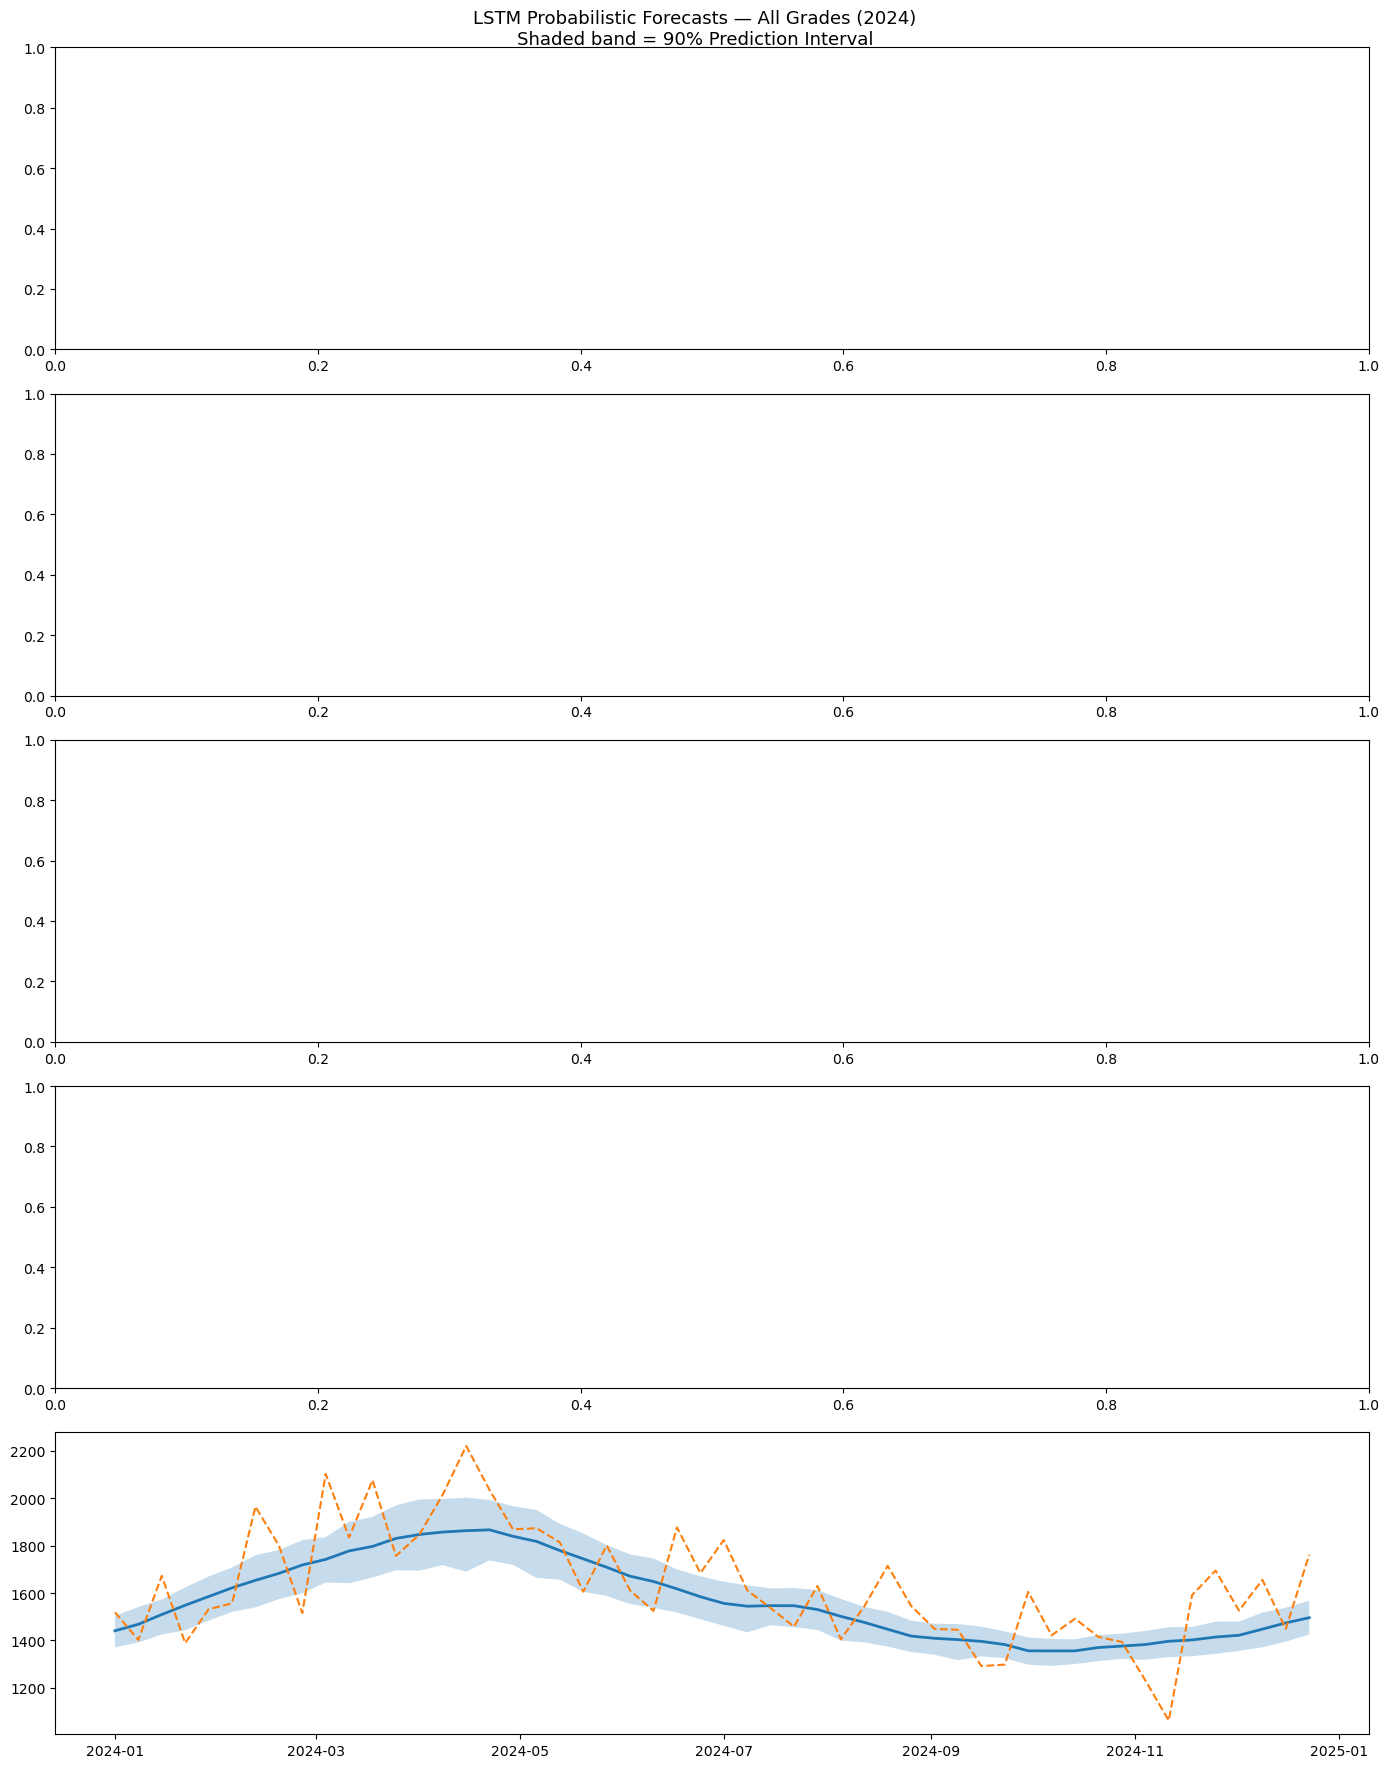

Saved → plots/lstm_probabilistic_all_grades.png


In [8]:
print("Generating probabilistic forecasts with MC Dropout...")

N_SAMPLES = 200  # number of stochastic forward passes

fig, axes = plt.subplots(len(grades_raw), 1, figsize=(14, 18))

for ax, grade in zip(axes, grades_raw):
    model = tf.keras.models.load_model(f'models/lstm_{grade}.keras')
    
    sub         = df[df['grade'] == grade].sort_values('week_start_date').reset_index(drop=True)
    scaler      = pickle.load(open(f'models/scaler_{grade}.pkl', 'rb'))
    train_raw   = sub[sub['year'] < 2024][FEATURES].values
    test_raw    = sub[sub['year'] >= 2024][FEATURES].values
    train_scaled = scaler.transform(train_raw)
    test_scaled  = scaler.transform(test_raw)
    full_scaled  = np.vstack([train_scaled, test_scaled])
    X_all, _    = build_sequences(full_scaled, LOOKBACK)
    split       = len(train_scaled) - LOOKBACK
    X_te        = X_all[split:]
    
    # Run N stochastic forward passes (Dropout stays ON)
    mc_preds = np.array([
        inverse_demand(model(X_te, training=True).numpy().flatten(), scaler, len(FEATURES))
        for _ in range(N_SAMPLES)
    ])
    
    mean_pred = mc_preds.mean(axis=0)
    lower_90  = np.percentile(mc_preds, 5,  axis=0)
    upper_90  = np.percentile(mc_preds, 95, axis=0)
    
    dates = sub[sub['year'] >= 2024]['week_start_date'].values

min_len = min(len(dates), len(mean_pred), len(lower_90), len(upper_90))

dates = dates[:min_len]
mean_pred = mean_pred[:min_len]
lower_90 = lower_90[:min_len]
upper_90 = upper_90[:min_len]

actuals = sub[sub['year'] >= 2024]['demand_kg'].values[:min_len]

ax.fill_between(dates, lower_90, upper_90, alpha=0.25, label='90% Prediction Interval')
ax.plot(dates, mean_pred, label='LSTM Mean Forecast', linewidth=2)
ax.plot(dates, actuals, label='Actual Demand', linewidth=1.5, linestyle='--')
    
    

plt.suptitle('LSTM Probabilistic Forecasts — All Grades (2024)\n'
             'Shaded band = 90% Prediction Interval', fontsize=13)
plt.tight_layout()
plt.savefig('plots/lstm_probabilistic_all_grades.png', dpi=150)
plt.show()
print("Saved → plots/lstm_probabilistic_all_grades.png")